In [1]:
import warnings
warnings.filterwarnings("ignore")
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D

I0000 00:00:1782296027.230416 1283282 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
tr_location="catdog_real_dataset_1/train"
val_location="catdog_real_dataset_1/validation"

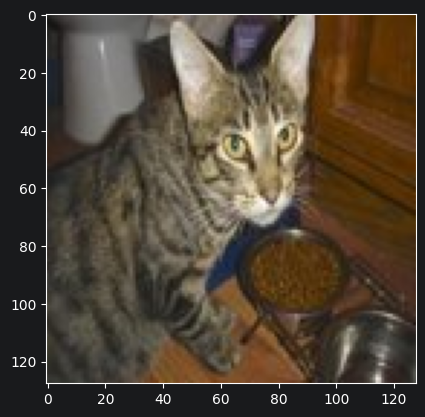

In [21]:
img = image.load_img(tr_location+"/cat/10.jpg")
plt.imshow(img)

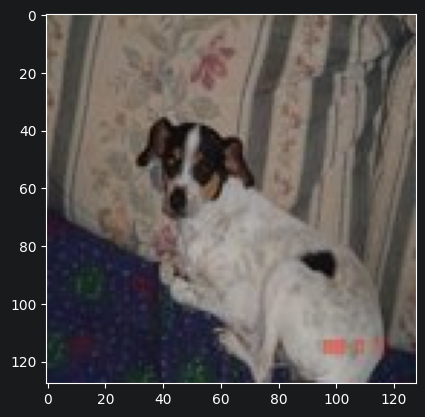

In [4]:
img = image.load_img(tr_location+"/dog/0.jpg")
plt.imshow(img)

In [5]:
train = ImageDataGenerator(rescale=1/255)
validation = ImageDataGenerator(rescale=1/255)

In [6]:
train_data = train.flow_from_directory(tr_location,
                                      target_size=(64,64),
                                      batch_size=8,
                                      class_mode="binary")
valid_data = validation.flow_from_directory(val_location,
                                      target_size=(64,64),
                                      batch_size=8,
                                      class_mode="binary")

Found 240 images belonging to 2 classes.
Found 60 images belonging to 2 classes.


In [7]:
train_data.class_indices

{'cat': 0, 'dog': 1}

In [8]:
## CNN MODEL
model = Sequential([
    Conv2D(16,(3,3),activation="relu",input_shape=(64,64,3)),
    MaxPooling2D(2,2),

    Conv2D(32,(3,3),activation="relu"),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation="relu"),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(64,activation="relu"),

    Dense(1,activation="sigmoid")
])

I0000 00:00:1782296030.762543 1283282 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2068 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171,169 (668.63 KB)

 Trainable params: 171,169 (668.63 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(loss="binary_crossentropy",optimizer=RMSprop(learning_rate=0.001),
             metrics=["accuracy"])

In [11]:
history=model.fit(train_data,epochs=10,validation_data=valid_data)

Epoch 1/10


I0000 00:00:1782296031.696267 1283282 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1782296032.290175 1283415 service.cc:153] XLA service 0x71d4b80325f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782296032.290192 1283415 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.2)
I0000 00:00:1782296032.313350 1283415 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1782296032.457006 1283415 cuda_dnn.cc:461] Loaded cuDNN version 92302
I0000 00:00:1782296032.466116 1283415 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1352__.35


19/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4920 - loss: 0.7308 

I0000 00:00:1782296037.221182 1283415 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.4917 - loss: 0.7057 - val_accuracy: 0.5000 - val_loss: 0.6948
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4958 - loss: 0.6960 - val_accuracy: 0.5000 - val_loss: 0.6942
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5333 - loss: 0.6957 - val_accuracy: 0.5667 - val_loss: 0.6888
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5667 - loss: 0.6889 - val_accuracy: 0.5333 - val_loss: 0.6847
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6375 - loss: 0.6701 - val_accuracy: 0.5000 - val_loss: 0.7184
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6875 - loss: 0.6203 - val_accuracy: 0.5167 - val_loss: 0.6903
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6833 - loss: 0.5876 - val_accuracy: 0.5333 - val_loss: 0.6899
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7458 - loss: 0.5424 - val_accuracy: 0.5667 - val_loss: 0.6869
Ep

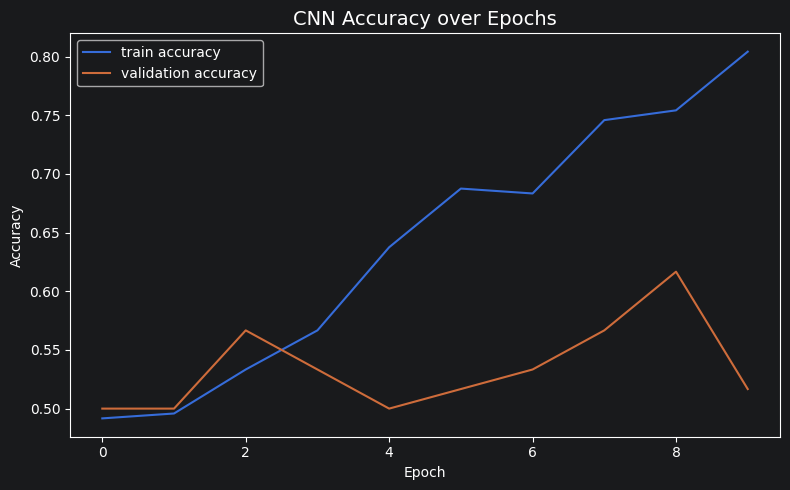

In [12]:
# plot accuracy across epochs for explainability
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"],label="train accuracy")
plt.plot(history.history["val_accuracy"],label="validation accuracy")
plt.title("CNN Accuracy over Epochs",fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

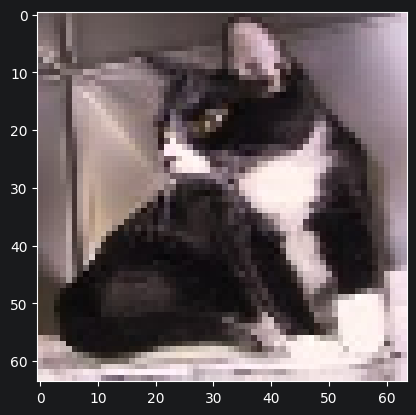

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
cat


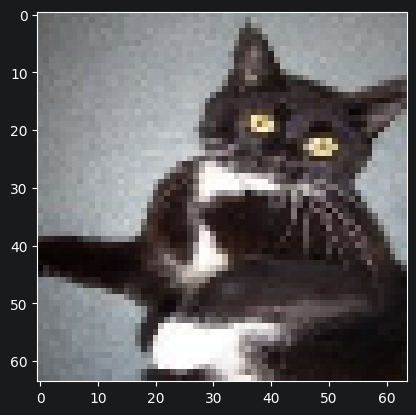

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
cat


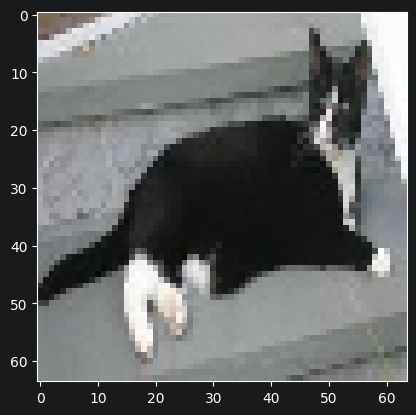

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
cat


In [13]:
path = val_location+"/cat"
for i in os.listdir(path)[:3]:
    img = image.load_img(path+"/"+i,target_size=(64,64))
    plt.imshow(img)
    plt.show()

    x = image.img_to_array(img)
    x = np.expand_dims(x,axis=0)
    pic = np.vstack([x])
    val = model.predict(pic)
    if val==0:
        print("cat")
    else:
        print("dog")